In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

In [2]:
# pre-processamento de dados
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224)
])

# Carrega o conjunto de treino
train_data = torchvision.datasets.MNIST(
    root='./data',       # pasta para salvar os dados
    train=True,         # busca pelo sub conjunto de treino.
    download=True,      # Download dos dados se necessário
    transform=transform,# transformação a ser aplicada
)

test_data = torchvision.datasets.MNIST(
    root='./data',       # pasta para salvar os dados
    train=False,         # busca pelo sub conjunto de teste.
    download=True,      # Download dos dados se necessário
    transform=transform,# transformação a ser aplicada
)

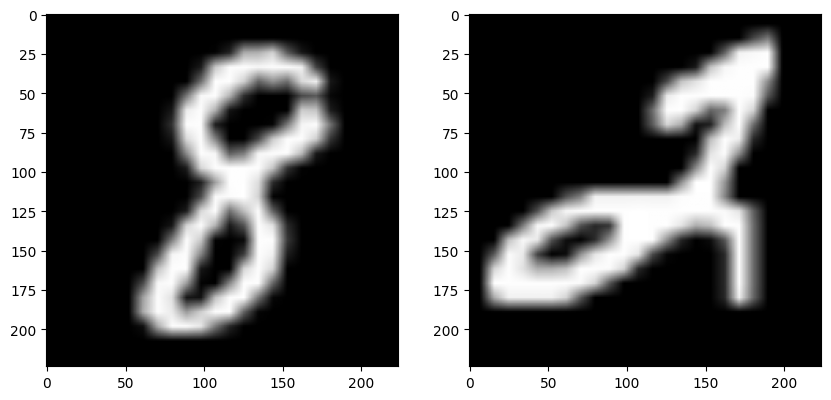

In [3]:
# visualizar duas imagens aleatórias da base de dados
indexes = [np.random.randint(0, len(train_data)), np.random.randint(0, len(train_data))]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(train_data[indexes[0]][0].numpy().transpose(1,2,0), cmap='gray')
axes[1].imshow(train_data[indexes[1]][0].numpy().transpose(1,2,0), cmap='gray')
plt.show()

In [4]:
# refine model

vgg_16_model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

num_classes = 10
in_features = vgg_16_model.classifier[6].in_features # 'in' neurons of classification layer
vgg_16_model.classifier[6] = torch.nn.Linear(in_features, num_classes)

new_first_conv = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)
vgg_16_model.features[0] = new_first_conv # features in vgg are thje convolutional layers

In [5]:
# medição do modelo sem refinamento
vgg_16_model.eval()

test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

device = "cuda" if torch.cuda.is_available() else 'cpu'

vgg_16_model.to(device)

correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    data = data.to(device)
    target = target.to(device)

    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct += 1

acc = correct/len(test_data)
print(f'Acurácia do modelo sem refinamento: {acc * 100}%')

Acurácia do modelo sem refinamento: 13.13%


In [7]:
optimizer = torch.optim.AdamW(vgg_16_model.parameters(), lr=1e-3)

loss_criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)


epochs = 1
for epoch in range(epochs):
    # Colocar modelo em modo train
    vgg_16_model.train()

    # colocar na gpu ou cpu
    vgg_16_model.to(device)

    # função de perda e acc para época
    train_loss = 0.0
    train_acc = 0.0
    valid_loss = 0.0
    valid_acc = 0.0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # limpando gradientes do otimizador
        optimizer.zero_grad()

        outputs = vgg_16_model(inputs)

        loss = loss_criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        train_acc += acc.item() * inputs.size(0)
        print("Batch number: {:03d}/{:03d}, Training Loss: {:.4f}, Training Accuracy: {:.4f}".format(batch_idx,len(train_data) // batch_size, loss.item(), acc.item()))

        

Batch number: 000/1875, Training Loss: 0.5988, Training Accuracy: 0.8438
Batch number: 001/1875, Training Loss: 0.6190, Training Accuracy: 0.8438
Batch number: 002/1875, Training Loss: 0.2069, Training Accuracy: 0.9062
Batch number: 003/1875, Training Loss: 0.1619, Training Accuracy: 0.9375
Batch number: 004/1875, Training Loss: 0.5262, Training Accuracy: 0.9062
Batch number: 005/1875, Training Loss: 0.0482, Training Accuracy: 0.9688
Batch number: 006/1875, Training Loss: 0.4146, Training Accuracy: 0.9062
Batch number: 007/1875, Training Loss: 0.8138, Training Accuracy: 0.8438
Batch number: 008/1875, Training Loss: 0.4213, Training Accuracy: 0.8438
Batch number: 009/1875, Training Loss: 0.3387, Training Accuracy: 0.9062
Batch number: 010/1875, Training Loss: 0.1921, Training Accuracy: 0.9062
Batch number: 011/1875, Training Loss: 0.3056, Training Accuracy: 0.9062
Batch number: 012/1875, Training Loss: 0.3844, Training Accuracy: 0.7812
Batch number: 013/1875, Training Loss: 0.4269, Trai

In [8]:
vgg_16_model.eval()

test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

device = "cuda" if torch.cuda.is_available() else 'cpu'

vgg_16_model.to(device)

correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    data = data.to(device)
    target = target.to(device)

    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct += 1

acc = correct/len(test_data)
print(f'Acurácia do modelo com refinamento: {acc * 100}%')

Acurácia do modelo com refinamento: 97.92%
